# Clasificación de Transacciones Fraudulentas en Retail: Limpieza de Datos, Modelado e Insights de Negocio

## Resumen Ejecutivo del Proyecto

Este proyecto desarrolla un modelo de *machine learning* para detectar fraude en canastas de compra en un contexto retail, donde el principal reto es clasificar correctamente una clase minoritaria (fraude) dentro de datos desbalanceados.

## Problema de negocio
El objetivo es reducir pérdidas y mejorar la priorización de revisiones operativas, identificando transacciones con alta probabilidad de fraude sin depender únicamente de reglas manuales.

## Enfoque técnico
- Limpieza y validación de datos para corregir inconsistencias en métricas clave (costo total y número de artículos).
- Análisis exploratorio para entender distribución de clases, frecuencia de productos y calidad de variables.
- Entrenamiento de un **Random Forest** con múltiples profundidades para comparar desempeño.
- Evaluación con métricas relevantes para clasificación desbalanceada: **AUC-ROC**, exactitud y matriz de confusión.
- Ajuste de umbral de decisión para mejorar la detección de fraude frente al comportamiento inicial del modelo.

## Resultados principales
- El modelo logra buena capacidad de discriminación (AUC sólida en pruebas).
- El ajuste de umbral permite aumentar la detección de casos fraudulentos, evitando clasificar casi todo como “no fraude”.
- Las variables de costo (mínimo, máximo y total) y ciertos productos de alta señal aparecen como factores importantes en la predicción.

## Valor para portafolio
Este trabajo evidencia competencias *end-to-end* de Data Science: entendimiento del problema de negocio, preparación robusta de datos, modelado supervisado, evaluación bajo desbalance de clases e interpretación de resultados para toma de decisiones.

# Importar librerias


In [ ]:
#!pip install dtreeviz  # versión 2.2.2

In [ ]:
import numpy as np
import pandas as pd

# Funciones específicas de Sckit-learn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier # add this import


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Para visualizar el árbol de decisión
import graphviz
import dtreeviz

# Importar funciones

In [ ]:
def describe_datos(df):
    unicos =[]
    for col in df:
        unicos.append(df[col].unique())
    unicos = pd.Series(unicos, index=df.columns)
    descripcion = pd.concat([df.dtypes, df.isna().sum(),df.nunique(),unicos], axis=1)
    descripcion.columns = ['dtypes', 'null','nunique','unique' ]
    return(descripcion)

In [ ]:
def grafica_roc(clf, y_test):
    '''Grafica la curva ROC para el conjunto de prueba'''
    y_test_score = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve( y_test, y_test_score)
    roc_auc = auc(fpr, tpr)  #Area bajo la curva (AUC, por sus siglas en inglés)
    plt.figure()
    plt.plot(fpr, tpr, label="Curva ROC (area = %0.2f)" % roc_auc)
    plt.plot([0, 1], [0, 1], "--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate ")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver operating characteristic")
    plt.legend(loc="lower right")
    plt.show()

# Importar dataset


In [ ]:
#Lectura de datos
data_raw = pd.read_csv('/content/FraudeCanastas.csv')
print(data_raw.shape)
data_raw.head(3)


(9319, 2457)


,ID,APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90,AUDIO ACCESSORIES | AB AUDIO | AB AUDIO GO AIR TRUE WIRELESS BLUETOOTH IN-EAR H,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE 2ND GENERATI,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE 2ND,AUDIO ACCESSORIES | APPLE | 2021 APPLE AIRPODS WITH MAGSAFE CHARGING CASE 3RD,AUDIO ACCESSORIES | APPLE | AIRPODS PRO,AUDIO ACCESSORIES | APPLE | APPLE AIRPODS MAX,...,WOMEN S NIGHTWEAR | ANYDAY RETAILER | ANYDAY RETAILER LEOPARD PRINT JERSEY PY,WOMEN S NIGHTWEAR | RETAILER | RETAILER CLEO VELOUR JOGGER LOUNGE PANT,WOMEN S NIGHTWEAR | SOSANDAR | SOSANDAR ZEBRA PRINT PYJAMA BOTTOMS BLACK 10,Nb_of_items,total_of_items,costo_total,costo_medio_item,costo_item_max,costo_item_min,fraud_flag
0,130,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2,2,1299,649.5,1299,0.0,1.0
1,195,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3,3,4119,1373.0,2470,0.0,1.0
2,217,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2,2,2806,1403.0,2799,7.0,1.0


In [ ]:
data_raw.shape

(9319, 2457)

# Análisis Exploratorio
En la base de datos hay:
**bold text**
- 85.5% canastas etiquetadas como no fraude (0)
- 14.5% canastas etiquetadas como fraude (1)


In [ ]:
#Aplicar función de descripción de columnas
describe_datos(data_raw)

,dtypes,null,nunique,unique
ID,int64,0,9319,"[130, 195, 217, 552, 854, 855, 856, 941, 1157,..."
APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90,float64,0,2,"[0.0, 1000.0]"
AUDIO ACCESSORIES | AB AUDIO | AB AUDIO GO AIR TRUE WIRELESS BLUETOOTH IN-EAR H,float64,0,2,"[0.0, 20.0]"
AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE,float64,0,8,"[0.0, 125.0, 119.0, 120.0, 500.0, 129.0, 109.0..."
AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE 2ND GENERATI,float64,0,8,"[0.0, 109.0, 100.0, 105.0, 104.0, 99.0, 119.0,..."
...,...,...,...,...
costo_total,int64,0,1639,"[1299, 4119, 2806, 1206, 1807, 1263, 942, 1199..."
costo_medio_item,float64,0,2034,"[649.5, 1373.0, 1403.0, 603.0, 66.925925925925..."
costo_item_max,int64,0,540,"[1299, 2470, 2799, 1199, 195, 280, 938, 929, 1..."
costo_item_min,float64,0,528,"[0.0, 7.0, 4.0, 1249.0, 25.0, 2470.0, 999.0, 1..."


### Eliminar canastas con NAs

Hay una fila con valores NAN en columnas de
- costo_total
- costo_medio_item
- costo_item_max
- costo_item_min
- fraud_flag
como no tiene el ID de una canasta, posiblemente es un error del csv.  

In [ ]:
# Contar NaNs in each column
column_nan_count_isna = data_raw.isna().sum()
print("NaN count per column using isna():")
print(column_nan_count_isna)

NaN count per column using isna():
ID                                                                                 0
APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90                                       0
AUDIO ACCESSORIES | AB AUDIO | AB AUDIO GO AIR TRUE WIRELESS BLUETOOTH IN-EAR H    0
AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE                  0
AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE 2ND GENERATI     0
                                                                                  ..
costo_total                                                                        0
costo_medio_item                                                                   0
costo_item_max                                                                     0
costo_item_min                                                                     0
fraud_flag                                                                         0
Length: 2457, dtype: int64


In [ ]:
#Eliminar registros con NaNs
data = data_raw.dropna()
# Usar columna ID como index del data frame
data = data.set_index('ID')
data.shape

(9319, 2456)

In [ ]:
#Contar canastas con fraude y no fraude
data["fraud_flag"].value_counts()

,count
fraud_flag,
0.0,8000
1.0,1319


In [ ]:
#Porcentaje canastas con fraude y no fraude
data["fraud_flag"].value_counts(normalize=True)

,proportion
fraud_flag,
0.0,0.858461
1.0,0.141539


In [ ]:
#Mostrar 5 canastas
data.head(5)

,APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90,AUDIO ACCESSORIES | AB AUDIO | AB AUDIO GO AIR TRUE WIRELESS BLUETOOTH IN-EAR H,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE 2ND GENERATI,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE 2ND,AUDIO ACCESSORIES | APPLE | 2021 APPLE AIRPODS WITH MAGSAFE CHARGING CASE 3RD,AUDIO ACCESSORIES | APPLE | AIRPODS PRO,AUDIO ACCESSORIES | APPLE | APPLE AIRPODS MAX,AUDIO ACCESSORIES | APPLE | APPLE AIRPODS MAX NOISE CANCELLING WIRELESS BLUETO,...,WOMEN S NIGHTWEAR | ANYDAY RETAILER | ANYDAY RETAILER LEOPARD PRINT JERSEY PY,WOMEN S NIGHTWEAR | RETAILER | RETAILER CLEO VELOUR JOGGER LOUNGE PANT,WOMEN S NIGHTWEAR | SOSANDAR | SOSANDAR ZEBRA PRINT PYJAMA BOTTOMS BLACK 10,Nb_of_items,total_of_items,costo_total,costo_medio_item,costo_item_max,costo_item_min,fraud_flag
ID,,,,,,,,,,,,,,,,,,,,,
130,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2,2,1299,649.500000,1299,0.0,1.0
195,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3,3,4119,1373.000000,2470,0.0,1.0
217,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2,2,2806,1403.000000,2799,7.0,1.0
552,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2,2,1206,603.000000,1199,7.0,1.0
854,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,19,27,1807,66.925926,195,4.0,1.0


## Validar columnas de costo total y Nb_of_items

Este paso se realiza para verificar la consistencia y calidad de las variables de costo_total y número de artículos únicos de las canastas.


### Hallazgos
- Hay 2499 productos.
- Se recalculó el costo_total, sumando por canasta los artículos con pesos distintos de cero y se obtuvieron  100% de canastas con el mismo valor de la columna costo_total.
- Se recalculó la variable Nb_of_items, sumando por canasta los productos con pesos distintos de cero y se obtuvieron 91% de canastas con el mismo número de items únicos reportados por la variable Nb_of_items. Por lo que el 9% de las canastas inconsistentes fueron excluidas del análisis.







In [ ]:
# Crear lista con columnas asociadas a productos
start_product = "APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90"
end_product = "WOMEN S NIGHTWEAR | SOSANDAR | SOSANDAR ZEBRA PRINT PYJAMA BOTTOMS BLACK 10"

productos = data.loc[:, start_product:end_product].columns.tolist()

# Seleccionar columnas de productos
data[productos]

,APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90,AUDIO ACCESSORIES | AB AUDIO | AB AUDIO GO AIR TRUE WIRELESS BLUETOOTH IN-EAR H,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE 2ND GENERATI,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE 2ND,AUDIO ACCESSORIES | APPLE | 2021 APPLE AIRPODS WITH MAGSAFE CHARGING CASE 3RD,AUDIO ACCESSORIES | APPLE | AIRPODS PRO,AUDIO ACCESSORIES | APPLE | APPLE AIRPODS MAX,AUDIO ACCESSORIES | APPLE | APPLE AIRPODS MAX NOISE CANCELLING WIRELESS BLUETO,...,WOMEN S FOOTWEAR | GABOR | GABOR BULNER LEATHER HI-TOP TRAINERS BLACK 6,WOMEN S FOOTWEAR | GABOR | GABOR BULNER LEATHER HI-TOP TRAINERS TAN 6,WOMEN S FOOTWEAR | GABOR | GABOR LANZAROTE SLIP ON SANDALS NAVY 6,WOMEN S FOOTWEAR | GOLA | GOLA GRANDSLAM MAMBA CHEETAH PRINT TRAINERS SILVER,WOMEN S FOOTWEAR | MINT VELVET | MINT VELVET CAMILLE LEATHER LOAFERS BLACK 7,WOMEN S FOOTWEAR | ROCKET DOG | ROCKET DOG CHEERY CANVAS TRAINERS WHITE 3,WOMEN S FOOTWEAR | UGG | UGG CLASSIC MINI II SHORT SHEEPSKIN BOOTS CHESTNUT,WOMEN S NIGHTWEAR | ANYDAY RETAILER | ANYDAY RETAILER LEOPARD PRINT JERSEY PY,WOMEN S NIGHTWEAR | RETAILER | RETAILER CLEO VELOUR JOGGER LOUNGE PANT,WOMEN S NIGHTWEAR | SOSANDAR | SOSANDAR ZEBRA PRINT PYJAMA BOTTOMS BLACK 10
ID,,,,,,,,,,,,,,,,,,,,,
130,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
195,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
217,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
552,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
854,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110381,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
111244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44253,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#Número de productos": 2449
len(productos)

2449

In [ ]:
#Primeros 3 productos"
productos[0:3]


['APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90',
 'AUDIO ACCESSORIES | AB AUDIO | AB AUDIO GO AIR TRUE WIRELESS BLUETOOTH IN-EAR H',
 'AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE']

In [ ]:
#Verificar costo total
data["costo_recalculado"] = data[productos].sum(axis='columns')
data["costo_diff"] = data["costo_total"]- data ['costo_recalculado']
data["costo_diff"].describe()

,costo_diff
count,9319.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [ ]:
data["costo_diff"].value_counts(normalize=True)

,proportion
costo_diff,
0.0,1.0


### Eliminar canastas con inconsistencias

Hallazgos:
La mayoría de las canastas (756 de 811) eliminadas están etiquetadas como no fraude.

In [ ]:
# Verificar número de items con valor distinto de cero en cada canasta para obtener variable de
# Número de artículos únicos
condicion_costo_diff_zero = data[productos]!=0
data["Nb_of_items_recalculada"]=condicion_costo_diff_zero.sum(axis='columns')
data["Nb_of_items_recalculada"].head(5)
data["Nb_of_items_diff"] = data["Nb_of_items"]- data ['Nb_of_items_recalculada']

In [ ]:
data["Nb_of_items_diff"].value_counts(normalize=True)

,proportion
Nb_of_items_diff,
0,0.908681
1,0.080588
2,0.006009
3,0.002683
4,0.000644
5,0.000429
6,0.000322
11,0.000215
12,0.000107


In [ ]:
data["Nb_of_items_diff"].value_counts()

,count
Nb_of_items_diff,
0,8468
1,751
2,56
3,25
4,6
5,4
6,3
11,2
12,1


In [ ]:
#Canastas eliminadas
canastas_eliminadas = data[data["Nb_of_items_diff"]!=0]
canastas_eliminadas.shape

(851, 2460)

In [ ]:
#La mayoría de las canastas eliminadas están etiquetadas como no fraude
canastas_eliminadas["fraud_flag"].value_counts()

,count
fraud_flag,
0.0,796
1.0,55


In [ ]:
#Datos con canastas eliminadas por inconsistencia en la variable Nb_of_items
data_proc=data[data["Nb_of_items_diff"]==0]
data_proc.drop(["Nb_of_items_diff","Nb_of_items_recalculada","costo_recalculado", "costo_diff"], axis=1, inplace = True)
data_proc.shape

<ipython-input-27-6f107c68f2e9>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


(8468, 2456)

In [ ]:
# Reconteo de canastas con fraude y no fraude
data_proc["fraud_flag"].value_counts()

,count
fraud_flag,
0.0,7204
1.0,1264


In [ ]:
data_proc["fraud_flag"].value_counts(normalize=True)

,proportion
fraud_flag,
0.0,0.850732
1.0,0.149268


# Análisis de productos más y menos frecuentes en las canastas
Hallazgos:

- De 2449 columnas que corresponde a productos, solamente 2,112 están en almenos una canasta.
- Los productos más frecuentes en las canastas son productos apple (computadoras,ipads y accesorios)
- Hay más de 1,400 productos que aparecen en 1 a 10 canastas.


In [ ]:
len(productos)

2449

In [ ]:
productos_boolean =  data_proc[productos]!=0
# Calcula el número de canastas por producto
productos_freq = pd.DataFrame(productos_boolean.sum(axis='rows').sort_values(ascending=False))
productos_freq.columns = ['Num_canastas'] # Rename the column
productos_freq.head(10)

,Num_canastas
FULFILMENT CHARGE | RETAILER | RETAILER,2006
COMPUTERS | APPLE | 2020 APPLE MACBOOK AIR 13 3 RETINA DISPLAY M1 PROC,1245
COMPUTERS | APPLE | 2020 APPLE MACBOOK PRO 13 TOUCH BAR M1 PROCESSOR 8,656
WARRANTY | RETAILER | RETAILER,650
COMPUTERS | APPLE | 2021 APPLE MACBOOK PRO 14 M1 PRO PROCESSOR 16GB RA,442
COMPUTERS | APPLE | 2021 APPLE MACBOOK PRO 16 M1 PRO PROCESSOR 16GB RA,270
COMPUTERS | APPLE | 2021 APPLE IPAD PRO 11 M1 PROCESSOR IOS WI-FI 128G,265
COMPUTERS | APPLE | 2021 APPLE IMAC 24 ALL-IN-ONE M1 PROCESSOR 8GB RAM,247
COMPUTER PERIPHERALS ACCESSORIES | APPLE | APPLE PENCIL 2ND GENERATION 2018 MATTE WHITE,242
COMPUTERS | APPLE | 2020 APPLE IPAD AIR 10 9 A14 BIONIC PROCESSOR IOS,235


In [ ]:
#Productos presentes en canastas
productos_presentes_en_canastas=productos_freq["Num_canastas"]>=1
len(productos_presentes_en_canastas[productos_presentes_en_canastas==True])


2112

<Axes: title={'center': 'Productos más frecuentes'}>

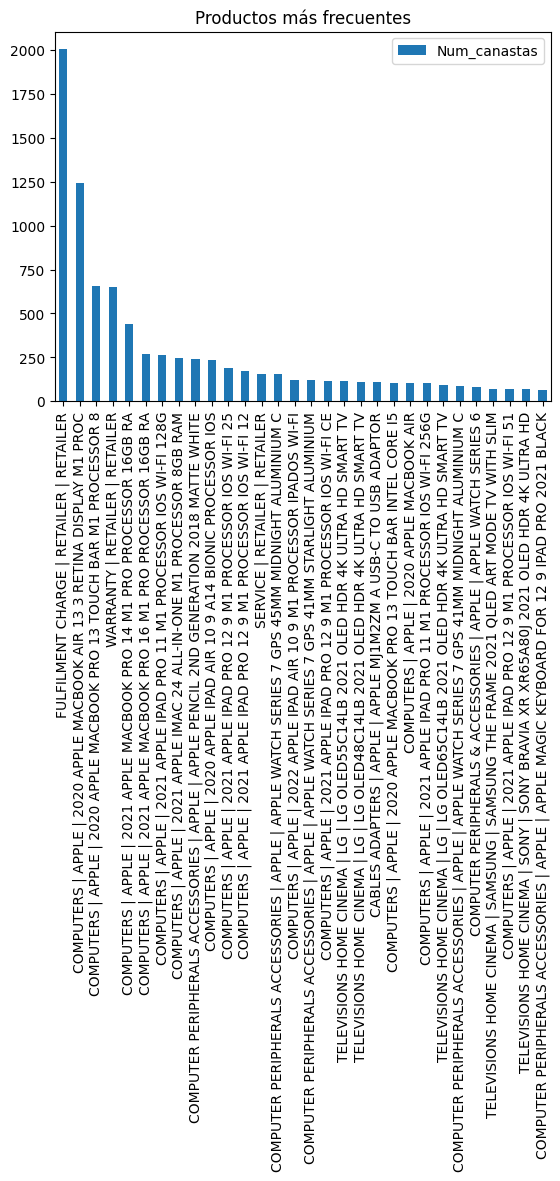

In [ ]:
#Productos en mayor número de canastas
productos_freq[productos_presentes_en_canastas==True].head(30).plot(kind='bar', title='Productos más frecuentes')

<Axes: title={'center': 'productos presentes solamente en 1 a 10 canastas'}, xlabel='Num_canastas'>

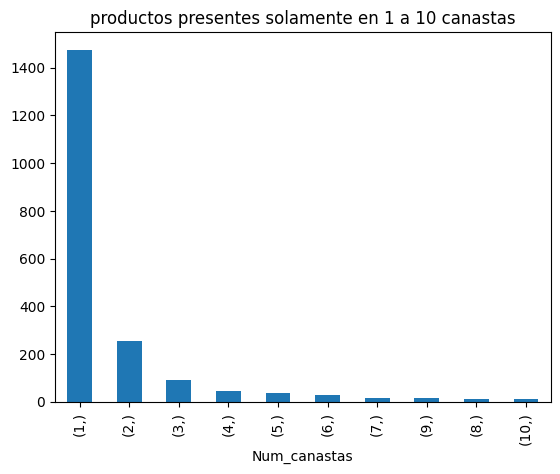

In [ ]:
#Productos en menor número de canastas
productos_freq[productos_presentes_en_canastas==True].value_counts().head(10).plot(kind='bar', title = 'productos presentes solamente en 1 a 10 canastas')

In [ ]:
productos_presentes_en_canastas[productos_presentes_en_canastas==True].index

Index(['FULFILMENT CHARGE | RETAILER | RETAILER',
       'COMPUTERS | APPLE | 2020 APPLE MACBOOK AIR 13 3 RETINA DISPLAY M1 PROC',
       'COMPUTERS | APPLE | 2020 APPLE MACBOOK PRO 13 TOUCH BAR M1 PROCESSOR 8',
       'WARRANTY | RETAILER | RETAILER',
       'COMPUTERS | APPLE | 2021 APPLE MACBOOK PRO 14 M1 PRO PROCESSOR 16GB RA',
       'COMPUTERS | APPLE | 2021 APPLE MACBOOK PRO 16 M1 PRO PROCESSOR 16GB RA',
       'COMPUTERS | APPLE | 2021 APPLE IPAD PRO 11 M1 PROCESSOR IOS WI-FI 128G',
       'COMPUTERS | APPLE | 2021 APPLE IMAC 24 ALL-IN-ONE M1 PROCESSOR 8GB RAM',
       'COMPUTER PERIPHERALS ACCESSORIES | APPLE | APPLE PENCIL 2ND GENERATION 2018 MATTE WHITE',
       'COMPUTERS | APPLE | 2020 APPLE IPAD AIR 10 9 A14 BIONIC PROCESSOR IOS',
       ...
       'COOKWARE | LE CREUSET | RETAILER',
       'DECORATIVE ACCESSORIES | ANYDAY RETAILER | ANYDAY RETAILER BEVELLED GLASS EDGE REC',
       'COMPUTER PERIPHERALS ACCESSORIES | APPLE | APPLE MAGIC TRACKPAD 2021 SILVER',
       'LAUN

In [ ]:
productos_ausentes_en_canastas=productos_presentes_en_canastas[productos_presentes_en_canastas==False].index
#Eliminar productos ausentes en canastas
all_columns = data_proc.columns
# Use the difference method to get the columns NOT in productos_ausentes_en_canastas
selected_columns = all_columns.difference(productos_ausentes_en_canastas)
# Now you can select these columns from the DataFrame
data_proc2 = data_proc[selected_columns]

# Elección del modelo
Hallazgos de los datos preprocesados:

- Hay 85.07% canastas (7,204) que no son fraude y 14.92% que son fraude (1,264).

- Al analizar los datos preprocesados, observamos que el 56% de las canastas tiene 1 artículo único y el 44.6% de canastas restantes de 2 a 23 artículos distintos. Adicionalmente cada canasta tiene 6 características númericas:
  - Nb_of_items
  - total_of_items
  - costo_total
  - costo_medio_item
  - costo_item_max
  - costo_item_min


- Esto sugiere que un modelo que tenga la propiedad de seleccionar un subconjunto de características con distintos umbrales, podría ser útil para clasificar las canastas fraude y no fraude.

- Adicionalmente sería idóneo contar con un modelo que elige distintas combinaciones de características para cada canasta, pues tienen de 1 a 23 artículos de un universo de productos de tamaño 2,112.



Modelo seleccionado:
- Con las observaciones descritas, decidí elegir el modelo de árbol de decisión para poder predecir canastas fraudulentas y no fraudulentas, y entender qué variables son más importantes para hacer la predicción. Debido a la gran diversidad de productos dentro de las canastas, propongo hacer un bosque aleatorio con distintos árboles de decisiones con profundidades de 6 a 12 caracterpisticas.

Evaluación del modelo:
- La evaluación del modelo se realiza con el calculo de la exactitud, la matriz de confusión y área debajo de la roc curve.







In [ ]:
data_proc2.shape

(8468, 2119)

In [ ]:
# Selecciona las columnas que describen a las canastas
metadata = data_proc2.loc[:,["Nb_of_items", "total_of_items", "costo_total", "costo_medio_item" ,"costo_item_max" ,"costo_item_min"]]
metadata.head(3)

,Nb_of_items,total_of_items,costo_total,costo_medio_item,costo_item_max,costo_item_min
ID,,,,,,
217,2,2,2806,1403.000000,2799,7.0
552,2,2,1206,603.000000,1199,7.0
855,8,9,1263,140.333333,280,4.0


In [ ]:
metadata.describe()

,Nb_of_items,total_of_items,costo_total,costo_medio_item,costo_item_max,costo_item_min
count,8468.000000,8468.000000,8468.000000,8468.000000,8468.000000,8468.000000
mean,1.645961,1.708668,1325.117029,935.440367,1192.359825,709.753543
std,1.148715,1.460729,1037.018817,750.769982,790.946726,856.783130
min,1.000000,1.000000,219.000000,84.384615,200.000000,3.000000
25%,1.000000,1.000000,849.000000,468.000000,749.000000,20.000000
50%,1.000000,1.000000,1124.000000,799.000000,1053.500000,479.000000
75%,2.000000,2.000000,1612.000000,1187.000000,1449.000000,1125.000000
max,23.000000,40.000000,24551.000000,19999.000000,19999.000000,19999.000000


In [ ]:
# Contar items únicos
metadata["Nb_of_items"].value_counts(normalize=True).sort_values()


,proportion
Nb_of_items,
15,0.000118
23,0.000118
21,0.000118
18,0.000118
20,0.000118
17,0.000118
13,0.000236
16,0.000354
14,0.000354


# Bosque Aleatorio con Árboles de decisión

In [ ]:
#Separar las etiquetas del conjunto de datos
y = data_proc2['fraud_flag'].astype(int)
X = data_proc2.drop('fraud_flag', axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    shuffle=True,
                                                    random_state=8)
# ¿Cómo son los conjuntos de entrenamiento y prueba?
print("TRAINING SET")
print("X: ", X_train.shape)
print("y: ", y_train.shape)
print('Canastas fraudulentas:{:7.3f}%'.format(y_train.mean()*100),'\n')

print("TEST SET")
print("X: ", X_test.shape)
print("y: ", y_test.shape)
print('Canastas fraudulentas:{:7.3f}%'.format(y_test.mean()*100))

TRAINING SET
X:  (6774, 2118)
y:  (6774,)
Canastas fraudulentas: 14.733% 

TEST SET
X:  (1694, 2118)
y:  (1694,)
Canastas fraudulentas: 15.702%


## Evaluación de profundidad de los árboles

Hallazgos:
- El modelo sobre ajusta en el entrenamiento a pesar de elegir una profundidad máxima de 6 a 12.

6
{6: 83.91918011924126}
{6: 85.2671981104222}
7
{6: 83.91918011924126, 7: 84.4077698332954}
{6: 85.2671981104222, 7: 85.2671981104222}
8
{6: 83.91918011924126, 7: 84.4077698332954, 8: 84.98126793753711}
{6: 85.2671981104222, 7: 85.2671981104222, 8: 85.2671981104222}
9
{6: 83.91918011924126, 7: 84.4077698332954, 8: 84.98126793753711, 9: 85.3946379601308}
{6: 85.2671981104222, 7: 85.2671981104222, 8: 85.2671981104222, 9: 85.2671981104222}
10
{6: 83.91918011924126, 7: 84.4077698332954, 8: 84.98126793753711, 9: 85.3946379601308, 10: 85.82919821637735}
{6: 85.2671981104222, 7: 85.2671981104222, 8: 85.2671981104222, 9: 85.2671981104222, 10: 85.2671981104222}
11
{6: 83.91918011924126, 7: 84.4077698332954, 8: 84.98126793753711, 9: 85.3946379601308, 10: 85.82919821637735, 11: 86.2003439010986}
{6: 85.2671981104222, 7: 85.2671981104222, 8: 85.2671981104222, 9: 85.2671981104222, 10: 85.2671981104222, 11: 85.29672276350753}
12
{6: 83.91918011924126, 7: 84.4077698332954, 8: 84.98126793753711, 9: 8

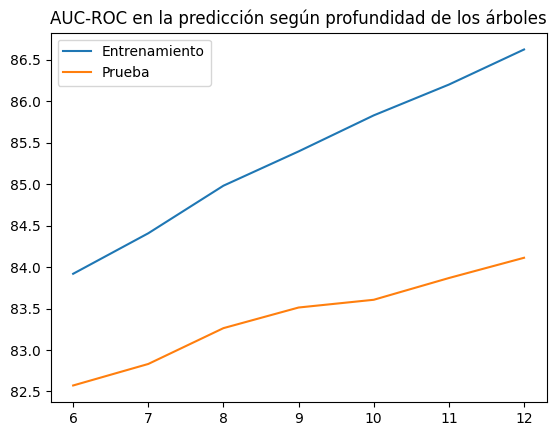

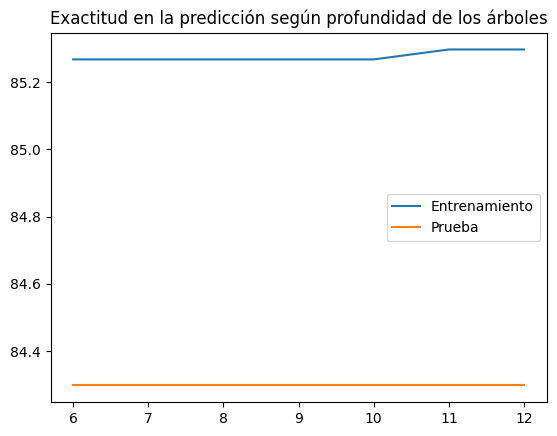

In [ ]:
# Entrenamiento y prueba del modelo con distintos niveles de profunidad

clf = {}
y_pred_train = {}
y_pred_test = {}
y_prob_train = {}
y_prob_test = {}
exactitud_train={}
exactitud_test = {}
auc_train = {}
auc_test = {}

for p in range(6,13):
    # Entrenamiento del modelo
    print(p)
    clf[p] = RandomForestClassifier(n_estimators=1500, max_depth = p ,
                                    random_state =25,
                                    criterion='entropy').fit(X_train, y_train)

    # Predicción y evaluación sobre el conjunto de entrenamiento
    y_pred_train[p] = clf[p].predict(X_train)
    # Probabilidad de fraude
    y_prob_train[p] = clf[p].predict_proba(X_train)[:,1]
    # Calcular exactitud sobre el conjunto de entrenamiento
    exactitud_train[p] = accuracy_score(y_train, y_pred_train[p])*100
    # Calcular tasa de falsos positivos y verdaderos positivos en el conjunto de entrenamiento
    fpr, tpr, thresholds = roc_curve(y_train, y_prob_train[p])
    # Calculate the AUC
    roc_auc_train = auc(fpr, tpr)
    # auc train
    auc_train[p] = roc_auc_train * 100
    print(auc_train)
    print(exactitud_train)


    # Predicción y evaluación sobre el conjunto de prueba
    y_pred_test[p] = clf[p].predict(X_test)
    # Probabilidad de fraude
    y_prob_test[p] = clf[p].predict_proba(X_test)[:,1]
    # Calcular exactitud sobre el conjunto de prueba
    exactitud_test[p] = accuracy_score(y_test, y_pred_test[p])*100

    fpr, tpr, thresholds = roc_curve(y_test, y_prob_test[p])
    # Calculate the AUC
    roc_auc_test = auc(fpr, tpr)
    # auc test
    auc_test[p] = roc_auc_test * 100


auc_df = pd.DataFrame( {'Entrenamiento':auc_train,
                           'Prueba': auc_test})

auc_df.plot.line(
    title ='AUC-ROC en la predicción según profundidad de los árboles')
plt.show()

exactitud_df = pd.DataFrame( {'Entrenamiento':exactitud_train,
                           'Prueba': exactitud_test})

exactitud_df.plot.line(
    title ='Exactitud en la predicción según profundidad de los árboles')
plt.show()




In [ ]:
profundidad_optima_auc = auc_df['Prueba'].idxmax()
profundidad_optima_auc

12

In [ ]:
profundidad_optima_exact = exactitud_df['Prueba'].idxmax()
profundidad_optima_exact

6

## Matriz de confusión con profundidad optima para bosque  con mejor roc_auc

Hallazgos:
- El bosque aleatorio predice que todas las canastas en el set de prueba no son fraude, esto muestra una gran limitante pues no se predice la clase minoritaría de canastas fraudulentas. Esto podría ser ocasionado por el desbalance de la base de datos.
- Se propone utilizar la curva roc, para elegir un umbral que permita predecir las canastas fraudulentas.

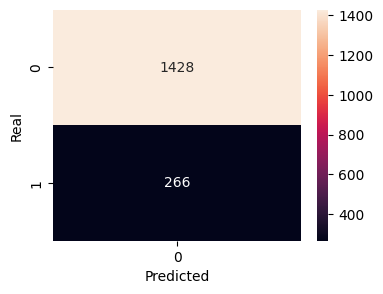

In [ ]:
#Matriz de confusión
model = clf[profundidad_optima_auc]
data = {'y_Real':y_test, 'y_Prediccion':model.predict(X_test)}

df = pd.DataFrame(data)
confusion_matrix = pd.crosstab(df['y_Real'], df['y_Prediccion'],
                               rownames=['Real'], colnames=['Predicted'])
fig, ax = plt.subplots(figsize=(4,3))
sns.heatmap(confusion_matrix, annot=True, fmt='g')
plt.show()

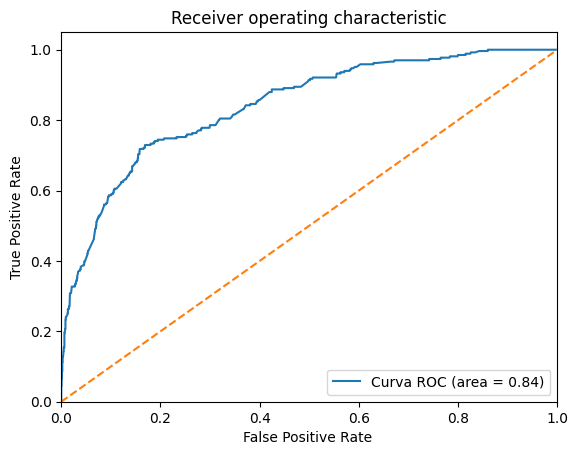

In [ ]:
grafica_roc(model, y_test)

## Selección del umbral de decisión

---
Hallazgos:
- Para evitar que todo el set de prueba sea predicho como canastas sin fraude, se obtuvo un umbral de la probabilidad de fraude > 0.15.
- 1106 canastas de no fraude fueron estimadas correctamente en el set de prueba, que corresponde a un True Positive Rate de	74.81%.
- 206 canastas de fraude fueron estimadas correctamente en el set de prueba, que corresponde a un True negative rate de 77.44%.



In [ ]:
y_test_score = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve( y_test, y_test_score)

roc_df = pd.DataFrame({'fpr': fpr,
                       'tpr':tpr,
                       'umbral_decision': thresholds,
                       'distancia': np.sqrt((fpr)**2 + (1-tpr)**2),
                       })
roc_df.sort_values('distancia').head(1)

,fpr,tpr,umbral_decision,distancia
166,0.193978,0.74812,0.157658,0.317916


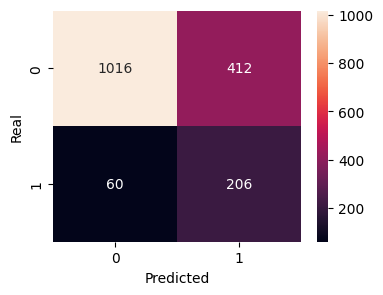

In [ ]:
#Matriz de confusión
umbral = 0.15 # por arriba del cual se clasificaría como fraude
prediccion_test = np.where( model.predict_proba(X_test)[:, 1] > umbral, 1, 0)
data_eva = {'y_Real':  y_test,
        'y_Prediccion': prediccion_test
        }

evaluacion_df = pd.DataFrame(data_eva)
confusion_matrix = pd.crosstab(evaluacion_df['y_Real'], evaluacion_df['y_Prediccion'], rownames=['Real'], colnames=['Predicted'])
fig, ax = plt.subplots(figsize=(4,3))
sns.heatmap(confusion_matrix, annot=True, fmt='g')
plt.show()

## Imporancia de Variables

Hallazgos:
- Las 3 variables más importantes son costo_item_min, costo_item_max y el costo total en la mayoría de los árboles del bosque.
- Los artículos que también destacan como varaibles más importantes son productos apple.

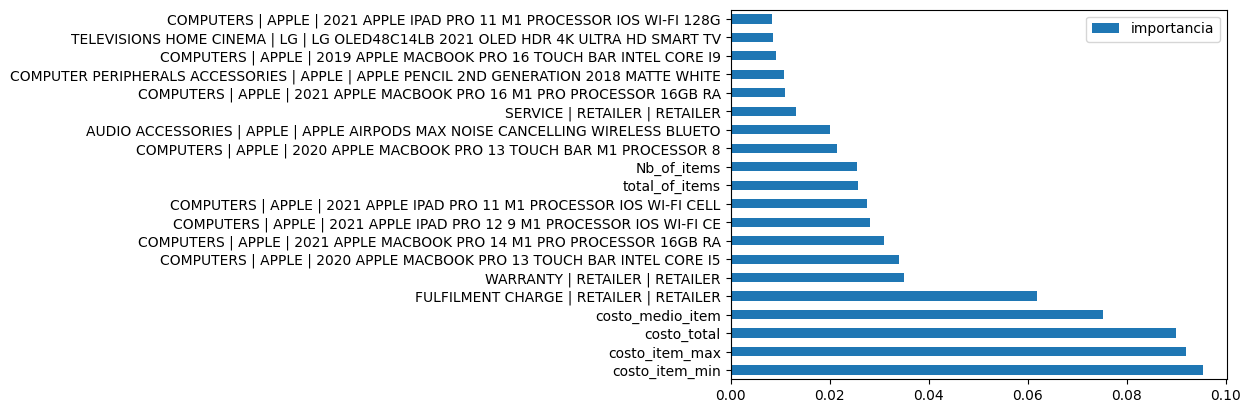

In [ ]:
model = clf[profundidad_optima_auc]
sorted_indices = np.argsort(model.feature_importances_)[::-1]
sorted_features = X.columns.values[sorted_indices]
sorted_importances = model.feature_importances_[sorted_indices]
sorted_importances_df = pd.DataFrame(sorted_importances, index=sorted_features, columns=['importancia'])
sorted_importances_df.head(20).plot(kind='barh')
plt.show()

# Visualización del primer árbol
-

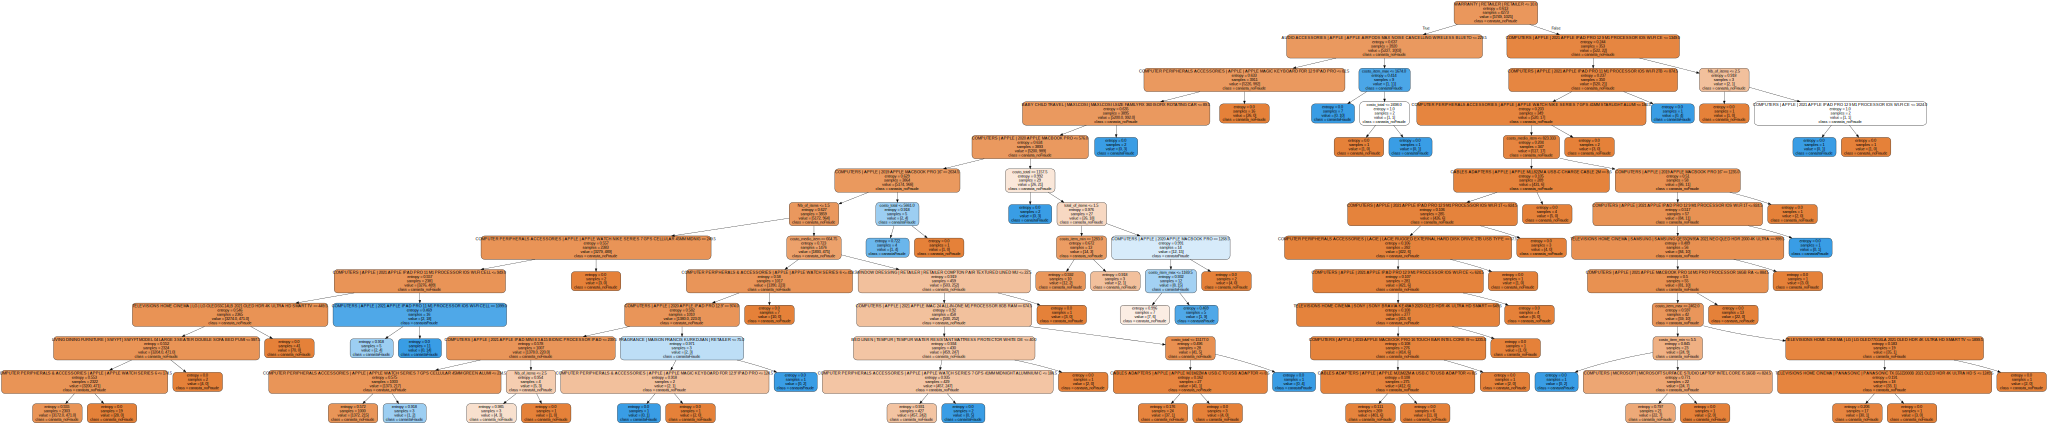

In [ ]:
from sklearn.tree import export_graphviz
import graphviz

# Access the first tree in the forest
tree = model.estimators_[0]

# Now use export_graphviz with the individual tree
dot_data = export_graphviz(tree,  # Pass the individual tree here
                           feature_names=X.columns,
                           class_names=['canasta_noFraude','canastaFraude'],
                           max_depth = profundidad_optima_auc,
                           rounded = True,
                           filled = True,
                           )

graph =  graphviz.Source(dot_data, format='png')

graph.render('arbol_decision')              # guarda el archivo .dot y la gráfica png
graph

# Resumen Ejecutivo

- El análisis exploratorio permitió detectar canastas con inconsistencias en el número de artículos únicos y productos ausentes en las canastas, así que la matriz de entrada fue manipulada para evitar estos casos.
-La selección del modelo fue un bosque aleatorio con 1,500 árboles de decisiones de profundidad máxima entre 6 y 12 variables. La métrica del área debajo de la curva roc, es más informativa para elegir la profundidad óptima de los árboles en el bosque que fue de 12 (con una auc de 0.84)
- Inicialmente todo el set de prueba era predicho como canastas sin fraude, por lo que se obtuvo un umbral de la probabilidad de canastas frauduletas de > 0.15, obteniendo un  True Positive Rate de 74.81% y un True negative rate de 77.44%.
- Las 3 variables más importantes son costo_item_min, costo_item_max y el costo total en la mayoría de los árboles del bosque.
- Los artículos que también destacan como varaibles más importantes son productos apple.

- Para comparar este clasificador, se propone explorar la reducción del número de productos con una regresión logística con penalización de ridge, y solamente usar un subconjunto de los productos, más las variables relacionadas al costo y número de artículos. Y con este nuevo conjunto de características construir otro bosque aleatorio.
